In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from collections import Counter  # Thư viện để đếm số lần xuất hiện của từ

In [2]:
path = '../../Data' 
files = [f for f in os.listdir(path) if f.endswith('.csv')]

# Khởi tạo dictionary để chứa các bản copy đã sạch (hoặc chuẩn bị làm sạch)
data_cleansed = {}

for file in files:
    # 1. Tách tên file để làm key (vd: 'sales_data.csv' -> 'sales_data')
    file_name = os.path.splitext(file)[0]
    full_path = os.path.join(path, file)
    
    # 2. Đọc file gốc
    df_temp = pd.read_csv(full_path)
    
    # 3. Tạo bản copy và lưu vào dictionary với định dạng key là df_<name>
    # Sử dụng .copy() để đảm bảo đây là một bản sao độc lập hoàn toàn
    dict_key = f"df_{file_name}"
    data_cleansed[dict_key] = df_temp.copy()
    
    print(f"Đã lưu bản copy vào dictionary: data_cleansed['{dict_key}']")

# Ví dụ cách truy cập sau khi load:
# print(data_cleansed['df_ten_file_cua_ban'].head())

Đã lưu bản copy vào dictionary: data_cleansed['df_customers']
Đã lưu bản copy vào dictionary: data_cleansed['df_geography']
Đã lưu bản copy vào dictionary: data_cleansed['df_inventory']
Đã lưu bản copy vào dictionary: data_cleansed['df_orders']


C:\Users\ngami\AppData\Local\Temp\ipykernel_26076\1533433001.py:13: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(full_path)


Đã lưu bản copy vào dictionary: data_cleansed['df_order_items']
Đã lưu bản copy vào dictionary: data_cleansed['df_payments']
Đã lưu bản copy vào dictionary: data_cleansed['df_products']
Đã lưu bản copy vào dictionary: data_cleansed['df_promotions']
Đã lưu bản copy vào dictionary: data_cleansed['df_returns']
Đã lưu bản copy vào dictionary: data_cleansed['df_reviews']
Đã lưu bản copy vào dictionary: data_cleansed['df_sales']
Đã lưu bản copy vào dictionary: data_cleansed['df_sample_submission']
Đã lưu bản copy vào dictionary: data_cleansed['df_shipments']
Đã lưu bản copy vào dictionary: data_cleansed['df_web_traffic']


**RETURN

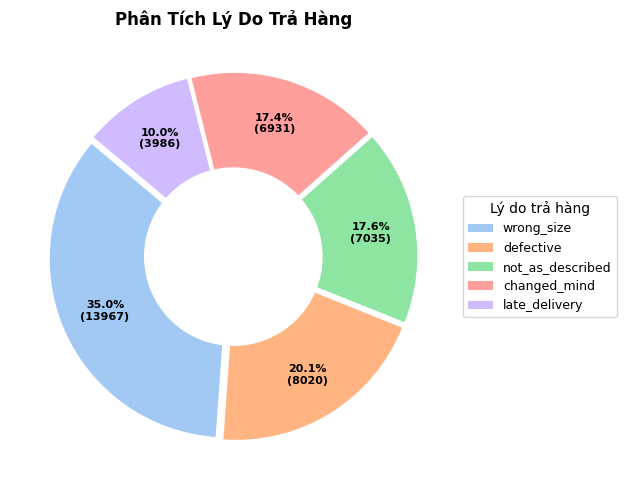

In [7]:
# Giả định dữ liệu đã có sẵn
df_returns = data_cleansed['df_returns']
reason_counts = df_returns['return_reason'].value_counts().reset_index()
reason_counts.columns = ['reason', 'count']

# 1. PHẢI ĐỊNH NGHĨA BIẾN NÀY TRƯỚC KHI VẼ
pct_idx = list(range(len(reason_counts)))

# Hàm định dạng nhãn bên trong (chỉ hiển thị số liệu để tránh chật chội)
def func(pct, allvals):
    absolute = int(round(pct/100.*sum(allvals)))
    return f"{pct:.1f}%\n({absolute:d})"

plt.figure(figsize=(7, 5)) # Size nhỏ gọn

# 2. Vẽ biểu đồ
wedges, texts, autotexts = plt.pie(
    reason_counts['count'], 
    autopct=lambda pct: func(pct, reason_counts['count']),
    startangle=140, 
    colors=sns.color_palette('pastel'),
    pctdistance=0.75,      # Đưa số liệu vào trong miếng bánh
    explode=[0.03] * len(reason_counts),
    textprops={'fontsize': 8, 'fontweight': 'bold'} # Chỉnh chữ số liệu nhỏ lại
)

# 3. Thêm Legend (Chú thích) ở bên cạnh để không lơ lửng
plt.legend(
    wedges, 
    reason_counts['reason'],
    title="Lý do trả hàng",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1), # Đẩy bảng chú thích ra ngoài phía bên phải
    fontsize=9
)

# Tạo hình tròn trắng ở giữa (Donut)
centre_circle = plt.Circle((0,0), 0.50, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Phân Tích Lý Do Trả Hàng', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Sai size (wrong_size) chiếm tỷ trọng cao nhất (~14,000)
→ Đây là vấn đề lớn nhất, cho thấy trải nghiệm chọn size chưa tốt hoặc thông tin size không rõ ràng.
Sản phẩm lỗi (defective) đứng thứ 2 (~8,000)
→ Chất lượng sản phẩm hoặc kiểm soát chất lượng (QC) đang có vấn đề đáng kể.
Không giống mô tả & đổi ý (not_as_described, changed_mind ~7,000)
→
“Không giống mô tả” phản ánh nội dung sản phẩm (hình ảnh/mô tả) chưa chính xác
“Đổi ý” cho thấy kỳ vọng khách hàng chưa được quản lý tốt
Giao hàng trễ (late_delivery ~4,000)
→ Ít hơn nhưng vẫn ảnh hưởng đến trải nghiệm tổng thể

# 🔍 **1. Giai đoạn tăng trưởng mạnh (2012–2016)**

**Hiện tượng:**
- Đơn hàng tăng nhanh: ~32k → ~82k
- Tần suất mua lại tăng: 1.45 → ~2.0
- Rating ổn định ~3.93–3.94

**Chẩn đoán:**
Doanh nghiệp đang scale rất tốt:
- Mở rộng tệp khách hàng
- Sản phẩm/giá phù hợp thị trường🔍 1. Giai đoạn tăng trưởng mạnh (2012–2016)
Hiện tượng:
Đơn hàng tăng nhanh: ~32k → ~82k
Tần suất mua lại tăng: 1.45 → ~2.0
Rating ổn định ~3.93–3.94
Chẩn đoán:
Doanh nghiệp đang scale rất tốt:
Mở rộng tệp khách hàng
Sản phẩm/giá phù hợp thị trường
Tần suất mua lại tăng → customer retention tốt
Rating không tăng nhiều → chất lượng ổn định nhưng chưa xuất sắc

👉 Insight:

Đây là giai đoạn “growth driven by acquisition + decent retention”, chưa phải nhờ trải nghiệm vượt trội.

⚠️ 2. Giai đoạn chững & suy giảm (2017–2019)
Hiện tượng:
Đơn hàng giảm: 82k → 69k → 41k
Tần suất mua lại giảm: 2.0 → 1.52
Rating gần như không đổi
Điểm bất thường:

👉 Rating không giảm nhưng khách vẫn rời bỏ

Chẩn đoán sâu:

Đây là dấu hiệu điển hình của:

1. “Hidden dissatisfaction” (bất mãn ngầm)
Rating ~3.9 là không tệ nhưng cũng không đủ tốt để giữ chân
Khách không complain mạnh → nhưng âm thầm rời đi
2. Trải nghiệm không khác biệt
Sản phẩm “ổn” nhưng:
Không có lý do quay lại
Dễ bị thay thế bởi đối thủ
3. Có thể xuất hiện vấn đề vận hành:

Dựa trên biểu đồ trả hàng trước đó:

Sai size, hàng lỗi, mô tả sai → tích tụ theo thời gian
→ làm giảm loyalty (thể hiện qua tần suất quay lại giảm)

👉 Insight quan trọng:

Doanh nghiệp không mất khách vì “tệ”, mà vì “không đủ tốt để giữ khách”

💥 3. Giai đoạn sụt giảm mạnh (2019–2020)
Hiện tượng:
Đơn hàng giảm cực mạnh: 69k → 41k → 34k
Tần suất mua lại chạm đáy: ~1.43
Rating lại tăng nhẹ (~3.98)
Chẩn đoán:
1. Tác động thị trường (rất lớn)
Đây trùng với giai đoạn COVID-19
→ Đứt gãy:
Chuỗi cung ứng
Logistic
Hành vi tiêu dùng
2. “Survivor bias” trong rating
Khách khó tính đã rời đi từ trước
Chỉ còn:
Nhóm khách trung thành / dễ tính hơn

→ Rating tăng nhưng không phản ánh tăng trưởng thực

👉 Insight:

Rating tăng trong khi doanh thu giảm = dấu hiệu nguy hiểm (false positive metric)

🧊 4. Giai đoạn hồi phục nhẹ (2021–2022)
Hiện tượng:
Đơn hàng hồi nhẹ (~34k → 36k)
Tần suất mua lại gần như không tăng (~1.44–1.46)
Rating ổn định
Chẩn đoán:
Doanh nghiệp chưa giải quyết gốc rễ vấn đề
Phục hồi chủ yếu do:
Thị trường hồi phục
Không phải do cải thiện nội tại

👉 Insight:

Business đang “stabilize ở mức thấp”, chưa quay lại quỹ đạo tăng trưởng
- Tần suất mua lại tăng → customer retention tốt
- Rating không tăng nhiều → chất lượng ổn định nhưng chưa xuất sắc

**👉 Insight:**  
**Đây là giai đoạn "growth driven by acquisition + decent retention", chưa phải nhờ trải nghiệm vượt trội.**

# ⚠️ **2. Giai đoạn chững & suy giảm (2017–2019)**

**Hiện tượng:**
- Đơn hàng giảm: 82k → 69k → 41k
- Tần suất mua lại giảm: 2.0 → 1.52
- Rating gần như không đổi

**Điểm bất thường:**  
**👉 Rating không giảm nhưng khách vẫn rời bỏ**

**Chẩn đoán sâu:**  
Đây là dấu hiệu điển hình của:

1. **"Hidden dissatisfaction" (bất mãn ngầm)**  
   Rating ~3.9 là không tệ nhưng cũng không đủ tốt để giữ chân  
   Khách không complain mạnh → nhưng âm thầm rời đi
2. **Trải nghiệm không khác biệt**  
   Sản phẩm "ổn" nhưng:  
   Không có lý do quay lại  
   Dễ bị thay thế bởi đối thủ
3. **Có thể xuất hiện vấn đề vận hành:**  
   Dựa trên biểu đồ trả hàng trước đó:  
   Sai size, hàng lỗi, mô tả sai → tích tụ theo thời gian  
   → làm giảm loyalty (thể hiện qua tần suất quay lại giảm)

**👉 Insight quan trọng:**  
**Doanh nghiệp không mất khách vì "tệ", mà vì "không đủ tốt để giữ khách"**

# 💥 **3. Giai đoạn sụt giảm mạnh (2019–2020)**

**Hiện tượng:**
- Đơn hàng giảm cực mạnh: 69k → 41k → 34k
- Tần suất mua lại chạm đáy: ~1.43
- Rating lại tăng nhẹ (~3.98)

**Chẩn đoán:**
1. **Tác động thị trường (rất lớn)**  
   Đây trùng với giai đoạn COVID-19  
   → Đứt gãy:  
   Chuỗi cung ứng  
   Logistic  
   Hành vi tiêu dùng
2. **"Survivor bias" trong rating**  
   Khách khó tính đã rời đi từ trước  
   Chỉ còn:  
   Nhóm khách trung thành / dễ tính hơn  
   → Rating tăng nhưng không phản ánh tăng trưởng thực

**👉 Insight:**  
**Rating tăng trong khi doanh thu giảm = dấu hiệu nguy hiểm (false positive metric)**

# 🧊 **4. Giai đoạn hồi phục nhẹ (2021–2022)**

**Hiện tượng:**
- Đơn hàng hồi nhẹ (~34k → 36k)
- Tần suất mua lại gần như không tăng (~1.44–1.46)
- Rating ổn định

**Chẩn đoán:**
Doanh nghiệp chưa giải quyết gốc rễ vấn đề  
Phục hồi chủ yếu do:  
Thị trường hồi phục  
Không phải do cải thiện nội tại

**👉 Insight:**  
**Business đang "stabilize ở mức thấp", chưa quay lại quỹ đạo tăng trưởng**

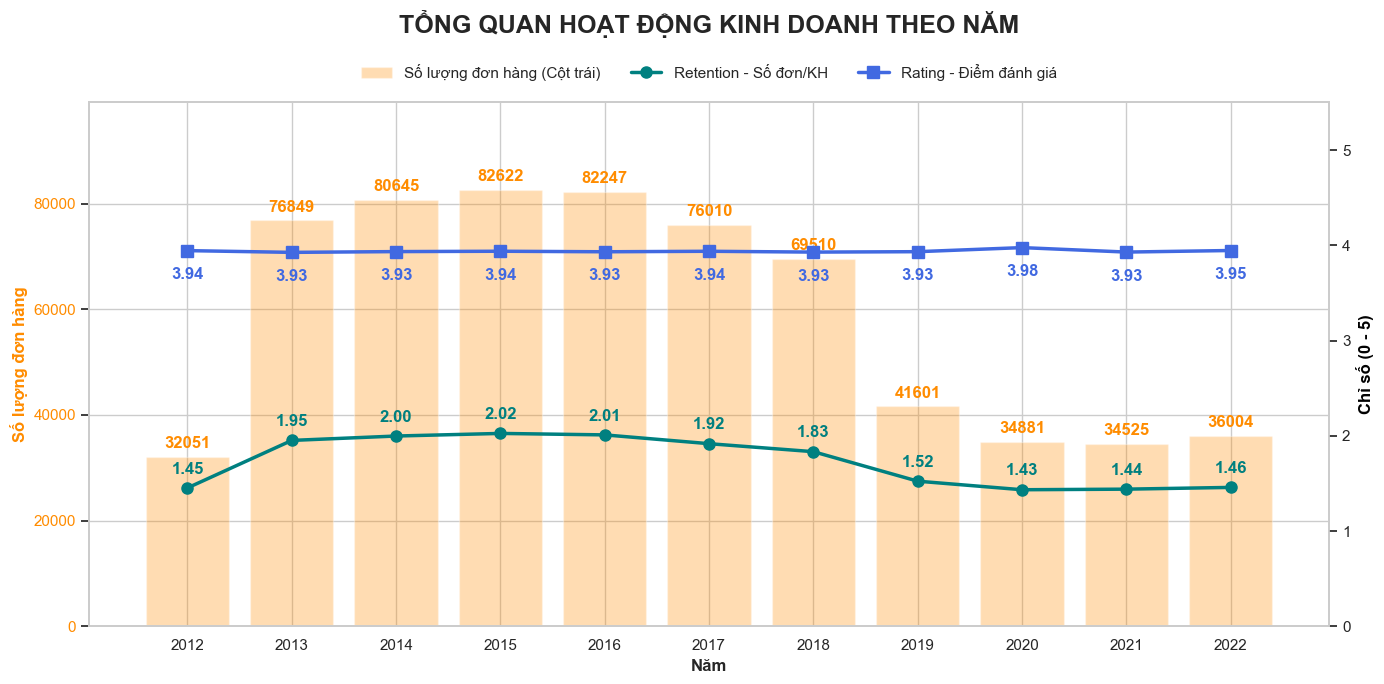

In [10]:
# ==============================
# 1. SETUP & CHUẨN BỊ DỮ LIỆU
# ==============================
sns.set_theme(style="whitegrid")

# Tạo bản sao để tránh ảnh hưởng dữ liệu gốc
df_orders = data_cleansed['df_orders'].copy()
df_reviews = data_cleansed['df_reviews'].copy()

# Chuyển đổi datetime và trích xuất năm
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
df_orders['year'] = df_orders['order_date'].dt.year

# --- A. Tính Volume Đơn hàng (Bar Chart) ---
yearly_order_volume = (
    df_orders.groupby('year')
    .size()
    .reset_index(name='total_orders')
)

# --- B. Tính Retention: Trung bình đơn hàng/khách hàng (Line 1) ---
customer_retention = (
    df_orders.groupby(['year', 'customer_id'])
    .size()
    .reset_index(name='order_count')
)
yearly_avg_orders = (
    customer_retention.groupby('year')['order_count']
    .mean()
    .reset_index()
)

# --- C. Tính Rating trung bình (Line 2) ---
# Merge orders với reviews để lấy mốc thời gian theo năm
df_merged_reviews = pd.merge(
    df_reviews, 
    df_orders[['order_id', 'year']], 
    on='order_id', 
    how='inner'
)
yearly_rating = (
    df_merged_reviews.groupby('year')['rating']
    .mean()
    .reset_index()
)

# ==============================
# 2. VẼ BIỂU ĐỒ TỔNG HỢP (COMBINED CHART)
# ==============================
fig, ax1 = plt.subplots(figsize=(14, 7))

# --- TRỤC Y TRÁI: Số lượng đơn hàng (Bar) ---
ax1.bar(
    yearly_order_volume['year'], 
    yearly_order_volume['total_orders'], 
    color='darkorange', alpha=0.3, label='Số lượng đơn hàng (Cột trái)'
)
ax1.set_ylabel('Số lượng đơn hàng', color='darkorange', fontweight='bold', fontsize=12)
ax1.tick_params(axis='y', labelcolor='darkorange')
ax1.set_ylim(0, yearly_order_volume['total_orders'].max() * 1.2) # Tạo khoảng trống phía trên cho labels

# Thêm data labels cho cột
for x, y in zip(yearly_order_volume['year'], yearly_order_volume['total_orders']):
    ax1.text(x, y + (yearly_order_volume['total_orders'].max() * 0.02), 
             f"{int(y)}", ha='center', color='darkorange', fontweight='bold')

# --- TRỤC Y PHẢI: Retention & Rating (Lines) ---
ax2 = ax1.twinx()

# Vẽ đường Retention
ax2.plot(
    yearly_avg_orders['year'], 
    yearly_avg_orders['order_count'], 
    marker='o', color='teal', linewidth=2.5, markersize=8, label='Retention - Số đơn/KH'
)

# Vẽ đường Rating
ax2.plot(
    yearly_rating['year'], 
    yearly_rating['rating'], 
    marker='s', color='royalblue', linewidth=2.5, markersize=8, label='Rating - Điểm đánh giá'
)

ax2.set_ylabel('Chỉ số (0 - 5)', color='black', fontweight='bold', fontsize=12)
ax2.set_ylim(0, 5.5) # Thang đo 0-5 phù hợp cho cả Rating và số đơn trung bình
ax2.grid(False)

# Thêm data labels cho Retention và Rating
for x, y in zip(yearly_avg_orders['year'], yearly_avg_orders['order_count']):
    ax2.text(x, y + 0.15, f"{y:.2f}", ha='center', color='teal', fontweight='bold')

for x, y in zip(yearly_rating['year'], yearly_rating['rating']):
    ax2.text(x, y - 0.3, f"{y:.2f}", ha='center', color='royalblue', fontweight='bold')

# ==============================
# 3. HOÀN THIỆN TIÊU ĐỀ & CHÚ THÍCH
# ==============================
# Gộp Legend từ cả 2 trục
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines + lines2, labels + labels2, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.1), 
    ncol=3, frameon=False, fontsize=11
)

plt.title('TỔNG QUAN HOẠT ĐỘNG KINH DOANH THEO NĂM', 
          fontweight='bold', fontsize=18, pad=50)

ax1.set_xlabel('Năm', fontweight='bold')
ax1.set_xticks(yearly_order_volume['year'])

plt.tight_layout()
plt.show()

In [11]:
# 1. Gộp bảng Review và Customers dựa trên customer_id
df_merged = pd.merge(df_reviews, df_customers[['customer_id', 'age_group']], on='customer_id', how='left')

# 2. Xử lý dữ liệu
# Group theo nhóm tuổi và rating để đếm số lượng
df_grouped = df_merged.groupby(['age_group', 'rating']).size().unstack(fill_value=0)

# 3. Vẽ biểu đồ
# Ta dùng trực tiếp df_grouped vì giá trị bên trong chính là số lượt review (Oy)
ax = df_grouped.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='RdYlGn', edgecolor='white')

# 4. Tính toán để hiển thị label % bên trong mỗi tầng màu
# Lấy tổng số review của từng nhóm tuổi (tổng chiều cao mỗi cột)
totals = df_grouped.sum(axis=1)

for i, age in enumerate(df_grouped.index):
    cum_height = 0 # Biến tích lũy để xác định vị trí đặt text
    for rating in df_grouped.columns:
        value = df_grouped.loc[age, rating]
        if value > 0:
            # Tính % của rating đó trong nhóm tuổi
            percentage = (value / totals[age]) * 100
            
            # Chỉ hiện text nếu phần trăm đủ lớn (> 3%) để không bị đè chữ
            if percentage > 3:
                ax.text(i, cum_height + value/2, f'{percentage:.1f}%', 
                        ha='center', va='center', color='black', fontsize=9, fontweight='bold')
        cum_height += value

# 5. Tùy chỉnh thẩm mỹ
plt.title('Số lượng Review theo Nhóm tuổi và Tỷ lệ Rating', fontweight='bold', fontsize=16, pad=20)
plt.xlabel('Nhóm tuổi', fontweight='bold', fontsize=12)
plt.ylabel('Tổng số lượt Review', fontweight='bold', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Điểm Rating', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

NameError: name 'df_customers' is not defined

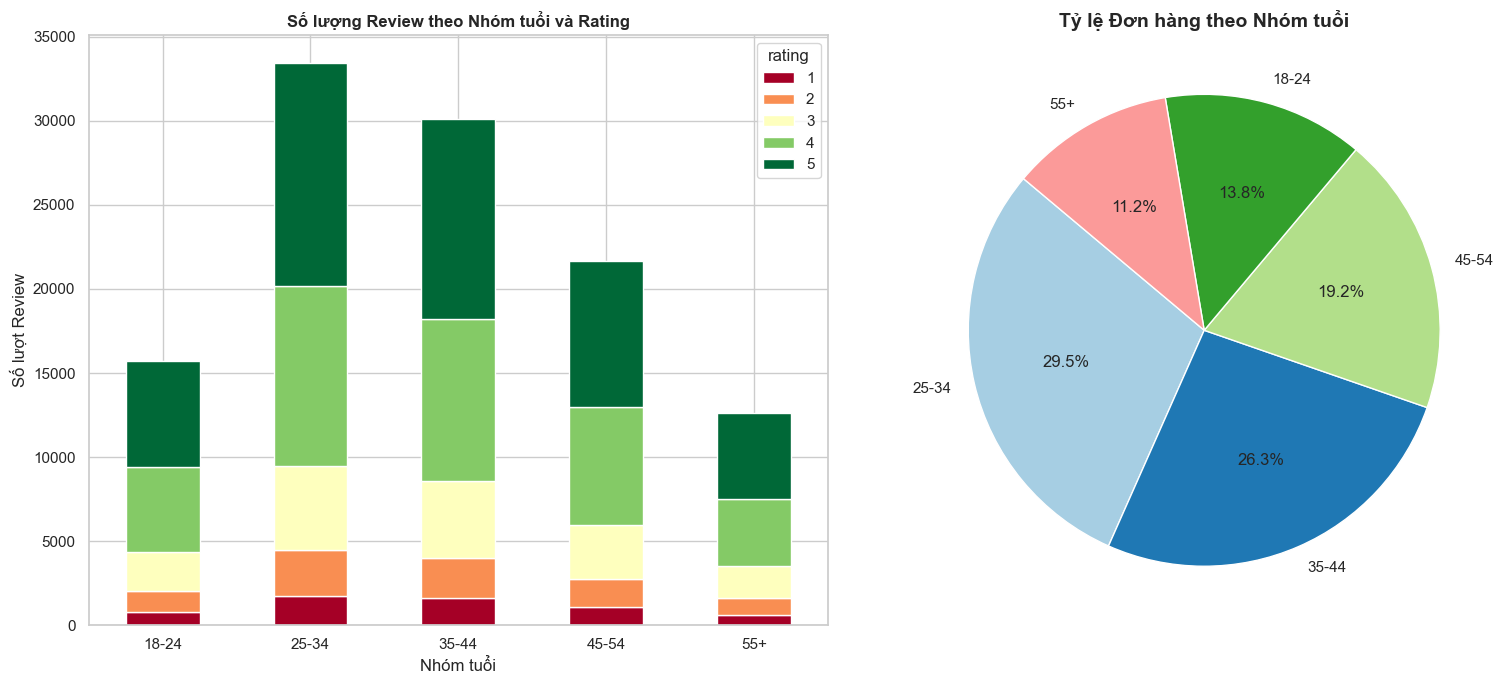

In [ ]:
# 1. Gộp bảng đơn hàng (df_orders) với bảng khách hàng (df_customers)
df_orders = data_cleansed['df_orders']
df_customers = data_cleansed['df_customers']   
# Mục tiêu: Lấy cột 'age_group' tương ứng với mỗi 'customer_id' trong đơn hàng
df_orders_merged = pd.merge(df_orders, df_customers[['customer_id', 'age_group']], on='customer_id', how='left')

# 2. Thống kê số lượng đơn hàng theo từng nhóm độ tuổi
# Chúng ta đếm sự xuất hiện của mỗi nhóm tuổi trong bảng vừa gộp
order_by_age = df_orders_merged['age_group'].value_counts()

# 3. Vẽ biểu đồ (vẫn giữ layout 2 biểu đồ nằm cạnh nhau để bạn dễ so sánh)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- BIỂU ĐỒ 1: Bar Chart (Dữ liệu Review bạn đã viết) ---
# (Phần này giữ nguyên logic của bạn để hiển thị song song)
df_grouped.plot(kind='bar', stacked=True, ax=ax1, colormap='RdYlGn', edgecolor='white')
ax1.set_title('Số lượng Review theo Nhóm tuổi và Rating', fontweight='bold')
ax1.set_xlabel('Nhóm tuổi')
ax1.set_ylabel('Số lượt Review')
ax1.tick_params(axis='x', rotation=0)

# --- BIỂU ĐỒ 2: Pie Chart (Số lượng Đơn hàng theo Nhóm tuổi) ---
# Sử dụng dữ liệu order_by_age vừa tính được
ax2.pie(order_by_age, 
        labels = order_by_age.index, 
        autopct = '%1.1f%%', 
        startangle = 140, 
        colors = plt.cm.Paired.colors,
        wedgeprops = {'edgecolor': 'white', 'linewidth': 1})

ax2.set_title('Tỷ lệ Đơn hàng theo Nhóm tuổi', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

Do nhóm độ tuổi 25-44 chiếm hơn 50% tổng số đơn hàng, nên ta khảo sát review title của nhóm này ở những rating 1-3 => tìm ra khuyết điểm để khắc phục

In [ ]:
# Giả sử bạn đã merge bảng reviews với bảng customers để có cột Age Group
df_review = data_cleansed['df_reviews']
df_customers = data_cleansed['df_customers']
df = pd.merge(df_review, df_customers, on='customer_id')

# 1. Lọc nhóm đối tượng mục tiêu: 25-44 tuổi và Rating từ 1-3
target_reviews = df[
    (df['age_group'].isin(['25-34', '35-44'])) & 
    (df['rating'] <= 3)
]

# 2. Tiền xử lý text đơn giản (chuyển chữ thường, xóa ký tự đặc biệt)
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

target_reviews['cleaned_title'] = target_reviews['review_title'].apply(clean_text)

# 3. Đếm các từ xuất hiện nhiều nhất (N-gram hoặc từng từ đơn)
all_words = ' '.join(target_reviews['cleaned_title']).split()

# Loại bỏ các từ dừng (stop words) phổ biến trong tiếng Việt/Anh nếu cần
stop_words = ['và', 'của', 'là', 'có', 'cho', 'the', 'is', 'it'] # Thêm tùy thực tế
words_filtered = [w for w in all_words if w not in stop_words and len(w) > 1]

common_issues = Counter(words_filtered).most_common(20)
print("Các từ khóa xuất hiện nhiều nhất trong review tiêu cực:")
for word, freq in common_issues:
    print(f"{word}: {freq}")

Các từ khóa xuất hiện nhiều nhất trong review tiêu cực:
not: 3368
mixed: 3259
feelings: 3259
average: 3218
product: 3218
decent: 3128
nothing: 3128
special: 3128
would: 2526
below: 1730
expectations: 1730
some: 1711
issues: 1711
reorder: 1687
very: 843
disappointed: 843
as: 842
described: 842
recommend: 839
poor: 806



Khi kết hợp Biểu đồ Lý do Trả hàng và Danh sách Từ khóa Review Tiêu cực, chúng ta thấy một bức tranh rất rõ ràng về sự đứt gãy giữa "Quảng cáo" và "Thực tế".

Dưới đây là các insight quan trọng nhất khi đặt hai dữ liệu này cạnh nhau:

1. Vấn đề cốt lõi: Sản phẩm không như mong đợi (The "Reality Gap")
Dữ liệu từ Chart: not_as_described (17.6%) là một trong những lý do hàng đầu.

Dữ liệu từ Review: Các từ khóa below, expectations, not, described xuất hiện với tần suất cực cao.

Kết luận: Khách hàng đang mua sản phẩm dựa trên một hình ảnh/mô tả "lung linh" nhưng thực tế nhận được lại khác xa. Điều này không chỉ gây trả hàng mà còn tạo ra tâm lý "mixed feelings" (cảm xúc lẫn lộn) – họ thấy sản phẩm dùng cũng tạm (decent, average) nhưng vì không giống mô tả nên vẫn cảm thấy bị lừa.

2. Sự lệch pha về Kích cỡ (Size) và Thông tin
Dữ liệu từ Chart: wrong_size chiếm tỷ trọng lớn nhất (35%).

Dữ liệu từ Review: Mặc dù từ "size" không nằm trong top từ đơn, nhưng cụm not, as, described (842 lần) và issues (1711 lần) giải thích lý do tại sao sai size.

Kết luận: Có thể bảng hướng dẫn size trên hệ thống đang không chuẩn, hoặc cách mô tả form dáng sản phẩm khiến khách hàng chọn nhầm. Đây là điểm gây lãng phí chi phí vận hành (logistic) lớn nhất cho doanh nghiệp.

3. Chất lượng "Tầm thường" so với Số tiền bỏ ra
Dữ liệu từ Chart: defective (20.1%) – Cứ 5 đơn trả hàng thì 1 đơn bị lỗi.

Dữ liệu từ Review: Các từ poor, average, nothing, special.

Kết luận: Sản phẩm không chỉ lỗi kỹ thuật (defective) mà còn bị đánh giá thấp về mặt giá trị cảm nhận. Khách hàng cảm thấy sản phẩm quá phổ thông, không có gì nổi bật so với kỳ vọng ban đầu, dẫn đến tâm lý dễ dàng thay đổi ý định (changed_mind: 17.4%).